# Storage query function demonstration

This notebook calls all five implemented query functions for three coverage cases:

1. an ERA5 query fully covered by storage,
2. a CARRA query spanning one covered and one uncovered spatial bucket, and
3. a CARRA query entirely south of the stored domain.

For every call, the notebook prints every field in `QueryResult`, `GroupResult`, and `SourceInfo`, displays the returned `xarray.Dataset`, and plots the returned scientific data when there is any. The executor also writes each returned group to its configured NetCDF output path.

In [1]:
from pathlib import Path
import sys

import cartopy.crs as ccrs
import matplotlib.pyplot as plt
from matplotlib.collections import PolyCollection
from matplotlib.patches import Patch
import numpy as np
from IPython.display import display


def find_project_root():
    # This works when Jupyter starts either in the repository or beside this notebook.
    current = Path.cwd().resolve()
    for candidate in (current, *current.parents):
        if (candidate / 'config.yaml').is_file() and (candidate / 'storage').is_dir():
            return candidate
    raise RuntimeError('Start Jupyter from the polar-is repository or one of its subdirectories.')


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from storage.query_data.executor import execute_query

print(f'Project root: {PROJECT_ROOT}')

Project root: /Users/bean/polar-is


## Result inspection and plotting helpers

The printer expands the nested result objects instead of relying on their abbreviated representations. Hit and miss cells are printed as `(bucket_id, timestamp)` pairs.

In [2]:
def sorted_coverage_cells(cells):
    return [
        (bucket_id, timestamp.isoformat())
        for bucket_id, timestamp in sorted(cells, key=lambda item: (item[0], item[1]))
    ]


def print_query_result(result):
    print('QueryResult')
    print(f'  query_id: {result.query_id}')
    print(f'  function: {result.function}')
    print(f'  warnings: {list(result.warnings)}')
    print(f'  unmatched_miss_set: {sorted_coverage_cells(result.unmatched_miss_set)}')
    print(f'  groups: {len(result.groups)}')

    for number, group in enumerate(result.groups, start=1):
        print(f'\n  GroupResult {number}')
        print(f'    group_id: {group.group_id}')
        print(f'    file_path: {group.file_path}')
        print(f'    units: {group.units!r}')
        print(f'    hit_set: {sorted_coverage_cells(group.hit_set)}')
        print(f'    miss_set: {sorted_coverage_cells(group.miss_set)}')
        print(f'    warnings: {list(group.warnings)}')

        source = group.source
        print('    source:')
        print(f'      repository: {source.repository}')
        print(f'      dataset: {source.dataset}')
        print(f'      variable: {source.variable}')
        print(f'      additional_parameters: {source.additional_parameters}')
        print(f'      native_temporal_resolutions: {source.native_temporal_resolutions}')
        print(f'      native_spatial_resolutions: {source.native_spatial_resolutions}')
        print(f'      block_ids: {source.block_ids}')
        print('    data:')
        display(group.data)

In [3]:
GEOGRAPHIC_CRS = ccrs.PlateCarree()


def display_longitudes(longitudes):
    # Stored longitudes are 0..360; plotting at -180..180 is easier to read.
    return (np.asarray(longitudes) + 180.0) % 360.0 - 180.0


def projection_for_group(group):
    attrs = group.data[group.source.variable].attrs
    if attrs.get('GRIB_gridType') != 'lambert':
        return GEOGRAPHIC_CRS

    central_longitude = display_longitudes(
        float(attrs['GRIB_LoVInDegrees'])
    ).item()
    return ccrs.LambertConformal(
        central_longitude=central_longitude,
        central_latitude=float(attrs['GRIB_LaDInDegrees']),
        standard_parallels=(
            float(attrs['GRIB_Latin1InDegrees']),
            float(attrs['GRIB_Latin2InDegrees']),
        ),
    )


def cell_polygons(group, longitude, latitude):
    # Query results remain flattened cells. For plotting only, make one
    # rectangle around each center using the source grid's cell size.
    attrs = group.data[group.source.variable].attrs
    projection = projection_for_group(group)
    factor = float(group.data.attrs.get('coarseness_factor', 1))

    if attrs.get('GRIB_gridType') == 'lambert':
        centers = projection.transform_points(
            GEOGRAPHIC_CRS, longitude, latitude
        )[:, :2]
        x_center, y_center = centers[:, 0], centers[:, 1]
        half_width = float(attrs['GRIB_DxInMetres']) * factor / 2.0
        half_height = float(attrs['GRIB_DyInMetres']) * factor / 2.0
    else:
        x_center, y_center = longitude, latitude
        native_resolution = float(group.source.native_spatial_resolutions[0])
        half_width = native_resolution * factor / 2.0
        half_height = native_resolution * factor / 2.0

    vertices = np.stack(
        [
            np.column_stack((x_center - half_width, y_center - half_height)),
            np.column_stack((x_center + half_width, y_center - half_height)),
            np.column_stack((x_center + half_width, y_center + half_height)),
            np.column_stack((x_center - half_width, y_center + half_height)),
        ],
        axis=1,
    )
    return projection, vertices


def plot_spatial_values(
    group, values, title, cmap='viridis', colorbar_label=None, matches=None
):
    data = group.data
    longitude = display_longitudes(data['longitude'].values)
    latitude = np.asarray(data['latitude'].values)
    values = np.asarray(values)
    valid = np.isfinite(values) & np.isfinite(longitude) & np.isfinite(latitude)

    projection, vertices = cell_polygons(
        group, longitude[valid], latitude[valid]
    )
    fig, ax = plt.subplots(
        figsize=(8, 6), subplot_kw={'projection': projection}
    )
    cells = PolyCollection(
        vertices, array=values[valid], cmap=cmap, edgecolors='none',
        transform=projection,
    )
    ax.add_collection(cells)

    if valid.any():
        longitude_padding = max(np.ptp(longitude[valid]) * 0.03, 0.2)
        latitude_padding = max(np.ptp(latitude[valid]) * 0.03, 0.2)
        ax.set_extent(
            [
                longitude[valid].min() - longitude_padding,
                longitude[valid].max() + longitude_padding,
                max(-90.0, latitude[valid].min() - latitude_padding),
                min(90.0, latitude[valid].max() + latitude_padding),
            ],
            crs=GEOGRAPHIC_CRS,
        )
        colorbar = fig.colorbar(cells, ax=ax, format='%.3f')
        colorbar.set_label(colorbar_label or group.source.variable)

    if matches is not None:
        matched = valid & np.asarray(matches, dtype=bool)
        if matched.any():
            _, matched_vertices = cell_polygons(
                group, longitude[matched], latitude[matched]
            )
            outlines = PolyCollection(
                matched_vertices, facecolors='none', edgecolors='crimson',
                linewidths=0.8, transform=projection, zorder=2,
            )
            ax.add_collection(outlines)
            ax.legend(
                handles=[Patch(facecolor='none', edgecolor='crimson',
                               label='predicate matched')]
            )

    gridlines = ax.gridlines(draw_labels=True, alpha=0.25)
    gridlines.top_labels = False
    gridlines.right_labels = False
    ax.set_title(title)
    plt.show()


def plot_group_result(group, function, filter_value=None):
    data = group.data
    variable = group.source.variable
    label = variable if group.units is None else f'{variable} ({group.units})'
    source_label = f'{group.source.repository} / {group.source.dataset}'

    if function == 'get-data':
        if data.sizes.get('timestamp', 0) == 0:
            return
        first_time = data['timestamp'].values[0]
        plot_spatial_values(
            group,
            data[variable].isel(timestamp=0).values,
            f'get-data: {source_label} at {first_time}',
            colorbar_label=label,
        )

    elif function in {'timeseries', 'find-time'}:
        timestamps = data['timestamp'].values
        values = data[variable].values
        fig, ax = plt.subplots(figsize=(9, 4))
        ax.plot(timestamps, values, marker='.', label=variable)
        if function == 'find-time':
            matches = data['matches'].values.astype(bool)
            ax.scatter(
                timestamps[matches], values[matches], color='crimson',
                zorder=3, label='predicate matched'
            )
            ax.axhline(filter_value, color='crimson', linestyle='--', alpha=0.6,
                       label=f'filter value = {filter_value}')
        ax.set(xlabel='Time', ylabel=label, title=f'{function}: {source_label}')
        ax.grid(alpha=0.25)
        ax.legend()
        fig.autofmt_xdate()
        plt.show()

    elif function == 'heatmap':
        plot_spatial_values(
            group, data[variable].values, f'heatmap: {source_label}',
            colorbar_label=label,
        )

    elif function == 'find-area':
        plot_spatial_values(
            group, data[variable].values,
            f'find-area: {source_label}; filter value = {filter_value}',
            colorbar_label=label, matches=data['matches'].values,
        )


def plot_query_result(result, filter_value=None):
    if not result.groups:
        print('No group data was returned, so there is nothing to plot.')
        return
    for group in result.groups:
        plot_group_result(group, result.function, filter_value=filter_value)

## Run all five functions

The same base query is used for each function. `find-time` and `find-area` use `gt 292.0` as a predicate.

In [4]:
FUNCTION_CALLS = (
    ('get-data', {}),
    ('timeseries', {}),
    ('heatmap', {}),
    ('find-time', {'predicate': 'gt', 'filter_value': 292.0}),
    ('find-area', {'predicate': 'gt', 'filter_value': 292.0}),
)


def run_scenario(name, base_query):
    results = {}
    for function, function_fields in FUNCTION_CALLS:
        query = {**base_query, 'function': function, **function_fields}
        print('\n' + '=' * 100)
        print(f'{name}: {function}')
        print('=' * 100)
        print('Query input:')
        display(query)

        result = execute_query(query)
        print_query_result(result)
        plot_query_result(result, filter_value=function_fields.get('filter_value'))
        results[function] = result
    return results

## Query inputs

All examples request daily, uncoarsened sea-surface temperature for January 2018. Repository and dataset filters make each coverage case deterministic. The partial CARRA box spans two capacity-1 longitude buckets: the first intersects the stored eastern CARRA domain and the second is outside it.

In [5]:
COMMON_QUERY = {
    'variable': 'sea_surface_temperature',
    'time_start': '2018-01',
    'time_end': '2018-01',
    'coarseness_factor': 1,
    'time_unit': 'Day',
    'aggregation_method': 'mean',
}

FULLY_COVERED_ERA5 = {
    **COMMON_QUERY,
    # 'region': {'west': 10.0, 'east': 20.0, 'south': 10.0, 'north': 20.0}, # over West Africa, only 3 water cells at Lake Chad
    'region': {'west': -40.0, 'east': -35.0, 'south': 20.0, 'north': 25.0},
    'repository': 'copernicusclimatedatastore',
    'dataset': 'era5_single_level',
}

PARTIALLY_COVERED_CARRA = {
    **COMMON_QUERY,
    'region': {'west': 60.0, 'east': 179.999, 'south': 65.0, 'north': 75.0},
    'repository': 'copernicusclimatedatastore',
    'dataset': 'carra_height',
    'additional_parameters': {'height': '15m'},
}

OUTSIDE_CARRA = {
    **COMMON_QUERY,
    'region': {'west': 10.0, 'east': 20.0, 'south': -20.0, 'north': -10.0},
    'repository': 'copernicusclimatedatastore',
    'dataset': 'carra_height',
    'additional_parameters': {'height': '15m'},
}

display({
    'fully covered ERA5': FULLY_COVERED_ERA5,
    'partially covered CARRA': PARTIALLY_COVERED_CARRA,
    'outside CARRA': OUTSIDE_CARRA,
})

{'fully covered ERA5': {'variable': 'sea_surface_temperature',
  'time_start': '2018-01',
  'time_end': '2018-01',
  'coarseness_factor': 1,
  'time_unit': 'Day',
  'aggregation_method': 'mean',
  'region': {'west': -40.0, 'east': -35.0, 'south': 20.0, 'north': 25.0},
  'repository': 'copernicusclimatedatastore',
  'dataset': 'era5_single_level'},
 'partially covered CARRA': {'variable': 'sea_surface_temperature',
  'time_start': '2018-01',
  'time_end': '2018-01',
  'coarseness_factor': 1,
  'time_unit': 'Day',
  'aggregation_method': 'mean',
  'region': {'west': 60.0, 'east': 179.999, 'south': 65.0, 'north': 75.0},
  'repository': 'copernicusclimatedatastore',
  'dataset': 'carra_height',
  'additional_parameters': {'height': '15m'}},
 'outside CARRA': {'variable': 'sea_surface_temperature',
  'time_start': '2018-01',
  'time_end': '2018-01',
  'coarseness_factor': 1,
  'time_unit': 'Day',
  'aggregation_method': 'mean',
  'region': {'west': 10.0, 'east': 20.0, 'south': -20.0, 'north

## 1. Fully covered ERA5 query


Fully covered ERA5: get-data
Query input:


{'variable': 'sea_surface_temperature',
 'time_start': '2018-01',
 'time_end': '2018-01',
 'coarseness_factor': 1,
 'time_unit': 'Day',
 'aggregation_method': 'mean',
 'region': {'west': -40.0, 'east': -35.0, 'south': 20.0, 'north': 25.0},
 'repository': 'copernicusclimatedatastore',
 'dataset': 'era5_single_level',
 'function': 'get-data'}

QueryResult
  query_id: 68c676f6c0ed23f676ead2fcf3c29be0
  function: get-data
  warnings: []
  unmatched_miss_set: []
  groups: 1

  GroupResult 1
    group_id: a01622840c54dfdaabc6d3dda165da4f
    file_path: /Users/bean/polar-is/storage/data/tmp/query_results/68c676f6c0ed23f676ead2fcf3c29be0/get-data/a01622840c54dfdaabc6d3dda165da4f.nc
    units: 'K'
    hit_set: [('r3_c5', '2018-01-01T00:00:00'), ('r3_c5', '2018-01-02T00:00:00'), ('r3_c5', '2018-01-03T00:00:00'), ('r3_c5', '2018-01-04T00:00:00'), ('r3_c5', '2018-01-05T00:00:00'), ('r3_c5', '2018-01-06T00:00:00'), ('r3_c5', '2018-01-07T00:00:00'), ('r3_c5', '2018-01-08T00:00:00'), ('r3_c5', '2018-01-09T00:00:00'), ('r3_c5', '2018-01-10T00:00:00'), ('r3_c5', '2018-01-11T00:00:00'), ('r3_c5', '2018-01-12T00:00:00'), ('r3_c5', '2018-01-13T00:00:00'), ('r3_c5', '2018-01-14T00:00:00'), ('r3_c5', '2018-01-15T00:00:00'), ('r3_c5', '2018-01-16T00:00:00'), ('r3_c5', '2018-01-17T00:00:00'), ('r3_c5', '2018-01-18T00:00:00'), ('r3_c5', '2018-01-1

<xarray.Dataset> Size: 144kB
Dimensions:                  (cell: 441, timestamp: 31)
Coordinates:
  * cell                     (cell) int64 4kB 0 1 2 3 4 ... 436 437 438 439 440
    latitude                 (cell) float64 4kB 20.0 20.0 20.0 ... 25.0 25.0
    longitude                (cell) float64 4kB 320.0 320.2 ... 324.8 325.0
    bucket_id                (cell) <U1 2kB 'r' 'r' 'r' 'r' ... 'r' 'r' 'r' 'r'
    cell_id                  (cell) <U12 21kB '20,320' '20,320.25' ... '25,325'
  * timestamp                (timestamp) datetime64[ns] 248B 2018-01-01 ... 2...
    expver                   (timestamp) <U4 496B '0001' '0001' ... '0001'
    number                   int64 8B 0
Data variables:
    sea_surface_temperature  (timestamp, cell) float64 109kB 298.5 ... 295.9
Attributes:
    query_id:               68c676f6c0ed23f676ead2fcf3c29be0
    group_id:               a01622840c54dfdaabc6d3dda165da4f
    function:               get-data
    repository:             copernicusclimatedatastore
    dataset:                era5_single_level
    variable:               sea_surface_temperature
    additional_parameters:  {}
    coarseness_factor:      1
    time_unit:              Day
    aggregation_method:     mean
    block_ids:              ["d8a724491452e6cb1ee286d86055c56b"]

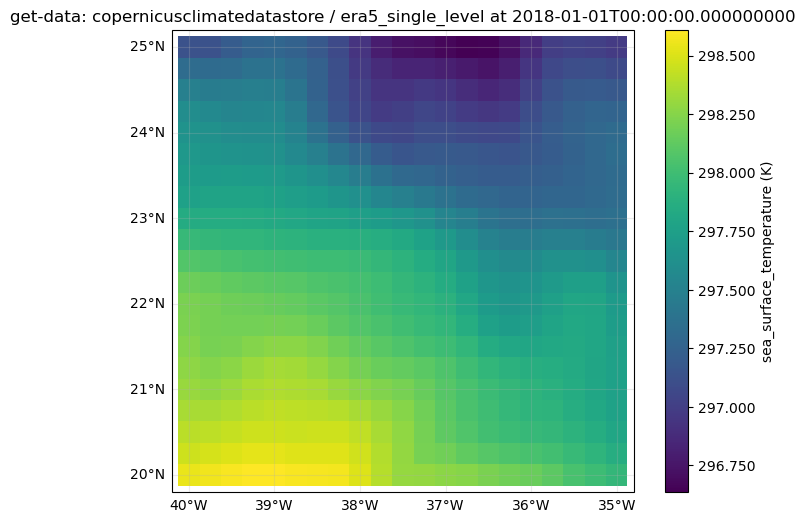


Fully covered ERA5: timeseries
Query input:


{'variable': 'sea_surface_temperature',
 'time_start': '2018-01',
 'time_end': '2018-01',
 'coarseness_factor': 1,
 'time_unit': 'Day',
 'aggregation_method': 'mean',
 'region': {'west': -40.0, 'east': -35.0, 'south': 20.0, 'north': 25.0},
 'repository': 'copernicusclimatedatastore',
 'dataset': 'era5_single_level',
 'function': 'timeseries'}

QueryResult
  query_id: 63f581e445b67ced31c0786e121f5416
  function: timeseries
  warnings: []
  unmatched_miss_set: []
  groups: 1

  GroupResult 1
    group_id: a01622840c54dfdaabc6d3dda165da4f
    file_path: /Users/bean/polar-is/storage/data/tmp/query_results/63f581e445b67ced31c0786e121f5416/timeseries/a01622840c54dfdaabc6d3dda165da4f.nc
    units: 'K'
    hit_set: [('r3_c5', '2018-01-01T00:00:00'), ('r3_c5', '2018-01-02T00:00:00'), ('r3_c5', '2018-01-03T00:00:00'), ('r3_c5', '2018-01-04T00:00:00'), ('r3_c5', '2018-01-05T00:00:00'), ('r3_c5', '2018-01-06T00:00:00'), ('r3_c5', '2018-01-07T00:00:00'), ('r3_c5', '2018-01-08T00:00:00'), ('r3_c5', '2018-01-09T00:00:00'), ('r3_c5', '2018-01-10T00:00:00'), ('r3_c5', '2018-01-11T00:00:00'), ('r3_c5', '2018-01-12T00:00:00'), ('r3_c5', '2018-01-13T00:00:00'), ('r3_c5', '2018-01-14T00:00:00'), ('r3_c5', '2018-01-15T00:00:00'), ('r3_c5', '2018-01-16T00:00:00'), ('r3_c5', '2018-01-17T00:00:00'), ('r3_c5', '2018-01-18T00:00:00'), ('r3_c5', '2018-

<xarray.Dataset> Size: 1kB
Dimensions:                  (timestamp: 31)
Coordinates:
  * timestamp                (timestamp) datetime64[ns] 248B 2018-01-01 ... 2...
    expver                   (timestamp) <U4 496B '0001' '0001' ... '0001'
    number                   int64 8B 0
Data variables:
    sea_surface_temperature  (timestamp) float64 248B 297.7 297.6 ... 296.6
Attributes:
    query_id:               63f581e445b67ced31c0786e121f5416
    group_id:               a01622840c54dfdaabc6d3dda165da4f
    function:               timeseries
    repository:             copernicusclimatedatastore
    dataset:                era5_single_level
    variable:               sea_surface_temperature
    additional_parameters:  {}
    coarseness_factor:      1
    time_unit:              Day
    aggregation_method:     mean
    block_ids:              ["d8a724491452e6cb1ee286d86055c56b"]

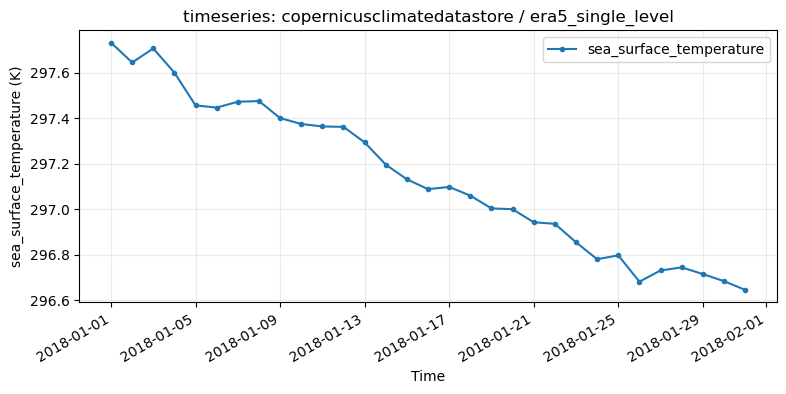


Fully covered ERA5: heatmap
Query input:


{'variable': 'sea_surface_temperature',
 'time_start': '2018-01',
 'time_end': '2018-01',
 'coarseness_factor': 1,
 'time_unit': 'Day',
 'aggregation_method': 'mean',
 'region': {'west': -40.0, 'east': -35.0, 'south': 20.0, 'north': 25.0},
 'repository': 'copernicusclimatedatastore',
 'dataset': 'era5_single_level',
 'function': 'heatmap'}

QueryResult
  query_id: 67ca1708a1ef0c2d5559092b19439db1
  function: heatmap
  warnings: []
  unmatched_miss_set: []
  groups: 1

  GroupResult 1
    group_id: a01622840c54dfdaabc6d3dda165da4f
    file_path: /Users/bean/polar-is/storage/data/tmp/query_results/67ca1708a1ef0c2d5559092b19439db1/heatmap/a01622840c54dfdaabc6d3dda165da4f.nc
    units: 'K'
    hit_set: [('r3_c5', '2018-01-01T00:00:00'), ('r3_c5', '2018-01-02T00:00:00'), ('r3_c5', '2018-01-03T00:00:00'), ('r3_c5', '2018-01-04T00:00:00'), ('r3_c5', '2018-01-05T00:00:00'), ('r3_c5', '2018-01-06T00:00:00'), ('r3_c5', '2018-01-07T00:00:00'), ('r3_c5', '2018-01-08T00:00:00'), ('r3_c5', '2018-01-09T00:00:00'), ('r3_c5', '2018-01-10T00:00:00'), ('r3_c5', '2018-01-11T00:00:00'), ('r3_c5', '2018-01-12T00:00:00'), ('r3_c5', '2018-01-13T00:00:00'), ('r3_c5', '2018-01-14T00:00:00'), ('r3_c5', '2018-01-15T00:00:00'), ('r3_c5', '2018-01-16T00:00:00'), ('r3_c5', '2018-01-17T00:00:00'), ('r3_c5', '2018-01-18T00:00:00'), ('r3_c5', '2018-01-19T

<xarray.Dataset> Size: 37kB
Dimensions:                  (cell: 441)
Coordinates:
  * cell                     (cell) int64 4kB 0 1 2 3 4 ... 436 437 438 439 440
    latitude                 (cell) float64 4kB 20.0 20.0 20.0 ... 25.0 25.0
    longitude                (cell) float64 4kB 320.0 320.2 ... 324.8 325.0
    bucket_id                (cell) <U1 2kB 'r' 'r' 'r' 'r' ... 'r' 'r' 'r' 'r'
    cell_id                  (cell) <U12 21kB '20,320' '20,320.25' ... '25,325'
    number                   int64 8B 0
Data variables:
    sea_surface_temperature  (cell) float64 4kB 298.1 298.1 ... 296.5 296.4
Attributes:
    query_id:               67ca1708a1ef0c2d5559092b19439db1
    group_id:               a01622840c54dfdaabc6d3dda165da4f
    function:               heatmap
    repository:             copernicusclimatedatastore
    dataset:                era5_single_level
    variable:               sea_surface_temperature
    additional_parameters:  {}
    coarseness_factor:      1
    time_unit:              Day
    aggregation_method:     mean
    block_ids:              ["d8a724491452e6cb1ee286d86055c56b"]

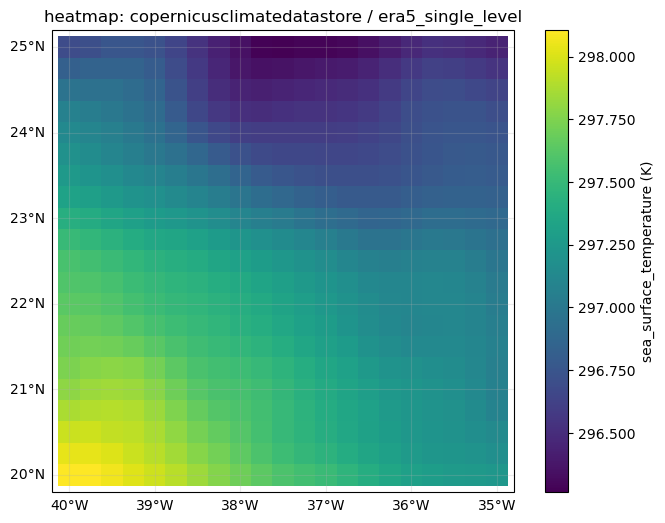


Fully covered ERA5: find-time
Query input:


{'variable': 'sea_surface_temperature',
 'time_start': '2018-01',
 'time_end': '2018-01',
 'coarseness_factor': 1,
 'time_unit': 'Day',
 'aggregation_method': 'mean',
 'region': {'west': -40.0, 'east': -35.0, 'south': 20.0, 'north': 25.0},
 'repository': 'copernicusclimatedatastore',
 'dataset': 'era5_single_level',
 'function': 'find-time',
 'predicate': 'gt',
 'filter_value': 292.0}

QueryResult
  query_id: 7e9e9b451d24ea48e1e85cbf4cf50ca8
  function: find-time
  warnings: []
  unmatched_miss_set: []
  groups: 1

  GroupResult 1
    group_id: a01622840c54dfdaabc6d3dda165da4f
    file_path: /Users/bean/polar-is/storage/data/tmp/query_results/7e9e9b451d24ea48e1e85cbf4cf50ca8/find-time/a01622840c54dfdaabc6d3dda165da4f.nc
    units: 'K'
    hit_set: [('r3_c5', '2018-01-01T00:00:00'), ('r3_c5', '2018-01-02T00:00:00'), ('r3_c5', '2018-01-03T00:00:00'), ('r3_c5', '2018-01-04T00:00:00'), ('r3_c5', '2018-01-05T00:00:00'), ('r3_c5', '2018-01-06T00:00:00'), ('r3_c5', '2018-01-07T00:00:00'), ('r3_c5', '2018-01-08T00:00:00'), ('r3_c5', '2018-01-09T00:00:00'), ('r3_c5', '2018-01-10T00:00:00'), ('r3_c5', '2018-01-11T00:00:00'), ('r3_c5', '2018-01-12T00:00:00'), ('r3_c5', '2018-01-13T00:00:00'), ('r3_c5', '2018-01-14T00:00:00'), ('r3_c5', '2018-01-15T00:00:00'), ('r3_c5', '2018-01-16T00:00:00'), ('r3_c5', '2018-01-17T00:00:00'), ('r3_c5', '2018-01-18T00:00:00'), ('r3_c5', '2018-01

<xarray.Dataset> Size: 1kB
Dimensions:                  (timestamp: 31)
Coordinates:
  * timestamp                (timestamp) datetime64[ns] 248B 2018-01-01 ... 2...
    expver                   (timestamp) <U4 496B '0001' '0001' ... '0001'
    number                   int64 8B 0
Data variables:
    sea_surface_temperature  (timestamp) float64 248B 297.7 297.6 ... 296.6
    matches                  (timestamp) bool 31B True True True ... True True
Attributes:
    query_id:               7e9e9b451d24ea48e1e85cbf4cf50ca8
    group_id:               a01622840c54dfdaabc6d3dda165da4f
    function:               find-time
    repository:             copernicusclimatedatastore
    dataset:                era5_single_level
    variable:               sea_surface_temperature
    additional_parameters:  {}
    coarseness_factor:      1
    time_unit:              Day
    aggregation_method:     mean
    block_ids:              ["d8a724491452e6cb1ee286d86055c56b"]

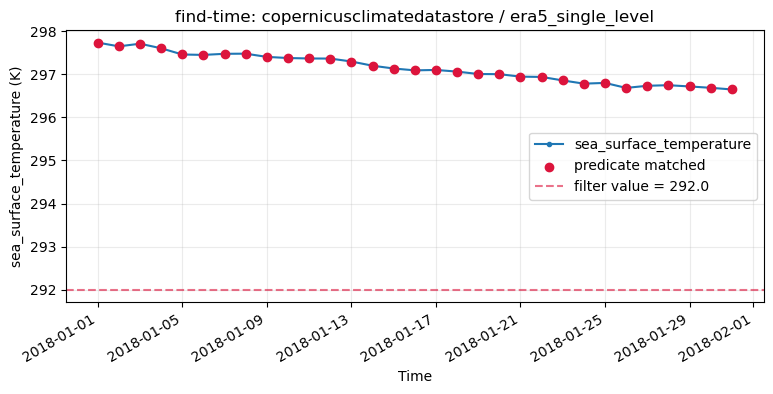


Fully covered ERA5: find-area
Query input:


{'variable': 'sea_surface_temperature',
 'time_start': '2018-01',
 'time_end': '2018-01',
 'coarseness_factor': 1,
 'time_unit': 'Day',
 'aggregation_method': 'mean',
 'region': {'west': -40.0, 'east': -35.0, 'south': 20.0, 'north': 25.0},
 'repository': 'copernicusclimatedatastore',
 'dataset': 'era5_single_level',
 'function': 'find-area',
 'predicate': 'gt',
 'filter_value': 292.0}

QueryResult
  query_id: 7a8b3660ac28a2d6578488345a3cf6b8
  function: find-area
  warnings: []
  unmatched_miss_set: []
  groups: 1

  GroupResult 1
    group_id: a01622840c54dfdaabc6d3dda165da4f
    file_path: /Users/bean/polar-is/storage/data/tmp/query_results/7a8b3660ac28a2d6578488345a3cf6b8/find-area/a01622840c54dfdaabc6d3dda165da4f.nc
    units: 'K'
    hit_set: [('r3_c5', '2018-01-01T00:00:00'), ('r3_c5', '2018-01-02T00:00:00'), ('r3_c5', '2018-01-03T00:00:00'), ('r3_c5', '2018-01-04T00:00:00'), ('r3_c5', '2018-01-05T00:00:00'), ('r3_c5', '2018-01-06T00:00:00'), ('r3_c5', '2018-01-07T00:00:00'), ('r3_c5', '2018-01-08T00:00:00'), ('r3_c5', '2018-01-09T00:00:00'), ('r3_c5', '2018-01-10T00:00:00'), ('r3_c5', '2018-01-11T00:00:00'), ('r3_c5', '2018-01-12T00:00:00'), ('r3_c5', '2018-01-13T00:00:00'), ('r3_c5', '2018-01-14T00:00:00'), ('r3_c5', '2018-01-15T00:00:00'), ('r3_c5', '2018-01-16T00:00:00'), ('r3_c5', '2018-01-17T00:00:00'), ('r3_c5', '2018-01-18T00:00:00'), ('r3_c5', '2018-01

<xarray.Dataset> Size: 37kB
Dimensions:                  (cell: 441)
Coordinates:
  * cell                     (cell) int64 4kB 0 1 2 3 4 ... 436 437 438 439 440
    latitude                 (cell) float64 4kB 20.0 20.0 20.0 ... 25.0 25.0
    longitude                (cell) float64 4kB 320.0 320.2 ... 324.8 325.0
    bucket_id                (cell) <U1 2kB 'r' 'r' 'r' 'r' ... 'r' 'r' 'r' 'r'
    cell_id                  (cell) <U12 21kB '20,320' '20,320.25' ... '25,325'
    number                   int64 8B 0
Data variables:
    sea_surface_temperature  (cell) float64 4kB 298.1 298.1 ... 296.5 296.4
    matches                  (cell) bool 441B True True True ... True True True
Attributes:
    query_id:               7a8b3660ac28a2d6578488345a3cf6b8
    group_id:               a01622840c54dfdaabc6d3dda165da4f
    function:               find-area
    repository:             copernicusclimatedatastore
    dataset:                era5_single_level
    variable:               sea_surface_temperature
    additional_parameters:  {}
    coarseness_factor:      1
    time_unit:              Day
    aggregation_method:     mean
    block_ids:              ["d8a724491452e6cb1ee286d86055c56b"]

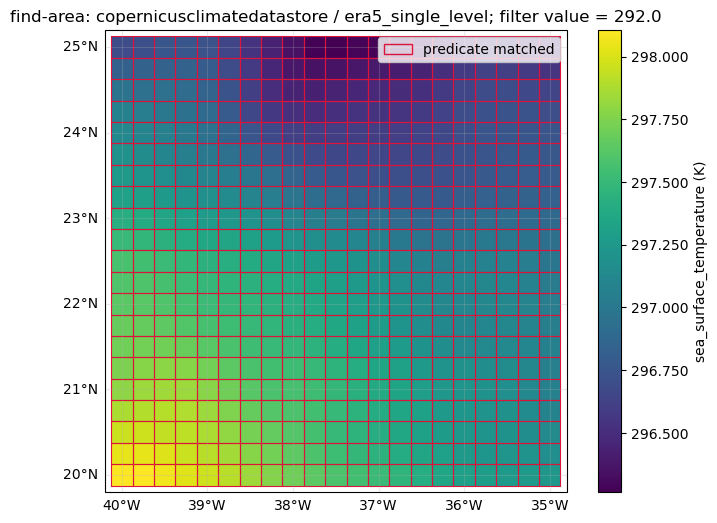

In [6]:
fully_covered_results = run_scenario('Fully covered ERA5', FULLY_COVERED_ERA5)

## 2. Partially covered CARRA query

Current coverage uses the `block_summary` envelope as the spatial coverage approximation. The miss set therefore reports missing `(bucket_id, timestamp)` cells, not individual missing source-grid points.

We change the filter value to `271.75`.

In [7]:
FUNCTION_CALLS = (
    ('get-data', {}),
    ('timeseries', {}),
    ('heatmap', {}),
    ('find-time', {'predicate': 'gt', 'filter_value': 271.75}),
    ('find-area', {'predicate': 'gt', 'filter_value': 271.75}),
)


def run_scenario(name, base_query):
    results = {}
    for function, function_fields in FUNCTION_CALLS:
        query = {**base_query, 'function': function, **function_fields}
        print('\n' + '=' * 100)
        print(f'{name}: {function}')
        print('=' * 100)
        print('Query input:')
        display(query)

        result = execute_query(query)
        print_query_result(result)
        plot_query_result(result, filter_value=function_fields.get('filter_value'))
        results[function] = result
    return results


Partially covered CARRA: get-data
Query input:


{'variable': 'sea_surface_temperature',
 'time_start': '2018-01',
 'time_end': '2018-01',
 'coarseness_factor': 1,
 'time_unit': 'Day',
 'aggregation_method': 'mean',
 'region': {'west': 60.0, 'east': 179.999, 'south': 65.0, 'north': 75.0},
 'repository': 'copernicusclimatedatastore',
 'dataset': 'carra_height',
 'additional_parameters': {'height': '15m'},
 'function': 'get-data'}

QueryResult
  query_id: ea2bf9536603309d20e72ad6deddff29
  function: get-data
  warnings: ['copernicusclimatedatastore/carra_height/sea_surface_temperature/{"height":"15m","region":"east"} is missing 31 of 62 bucket/time cells at the exact requested grid.']
  unmatched_miss_set: []
  groups: 1

  GroupResult 1
    group_id: d1df36096318efad6597358087ce69e8
    file_path: /Users/bean/polar-is/storage/data/tmp/query_results/ea2bf9536603309d20e72ad6deddff29/get-data/d1df36096318efad6597358087ce69e8.nc
    units: 'K'
    hit_set: [('r5_c1', '2018-01-01T00:00:00'), ('r5_c1', '2018-01-02T00:00:00'), ('r5_c1', '2018-01-03T00:00:00'), ('r5_c1', '2018-01-04T00:00:00'), ('r5_c1', '2018-01-05T00:00:00'), ('r5_c1', '2018-01-06T00:00:00'), ('r5_c1', '2018-01-07T00:00:00'), ('r5_c1', '2018-01-08T00:00:00'), ('r5_c1', '2018-01-09T00:00:00'), ('r5_c1', '2018-01-10T00:00:00'), ('r5_c1', '2018-01-11T00:00:00'), ('r5_c1', '2018-01-12T00:00:00'), ('r5_c1', '2018-01-13T00:00:00'), ('r5_c1', '2018-01-14T00:

<xarray.Dataset> Size: 9MB
Dimensions:                  (cell: 22447, timestamp: 31)
Coordinates:
  * cell                     (cell) int64 180kB 0 1 2 3 ... 22444 22445 22446
    latitude                 (cell) float64 180kB 74.99 74.96 ... 69.22 69.19
    longitude                (cell) float64 180kB 60.06 60.05 ... 65.27 65.26
    bucket_id                (cell) <U1 90kB 'r' 'r' 'r' 'r' ... 'r' 'r' 'r' 'r'
    cell_id                  (cell) <U27 2MB '74.9871532847,60.0577405395' .....
  * timestamp                (timestamp) datetime64[ns] 248B 2018-01-01 ... 2...
    expver                   (timestamp) <U4 496B 'prod' 'prod' ... 'prod'
Data variables:
    sea_surface_temperature  (timestamp, cell) float64 6MB 271.5 271.6 ... 271.5
Attributes:
    query_id:               ea2bf9536603309d20e72ad6deddff29
    group_id:               d1df36096318efad6597358087ce69e8
    function:               get-data
    repository:             copernicusclimatedatastore
    dataset:                carra_height
    variable:               sea_surface_temperature
    additional_parameters:  {"height": "15m", "region": "east"}
    coarseness_factor:      1
    time_unit:              Day
    aggregation_method:     mean
    block_ids:              ["afaa96a63416b0df4d654ea1fe51b743"]

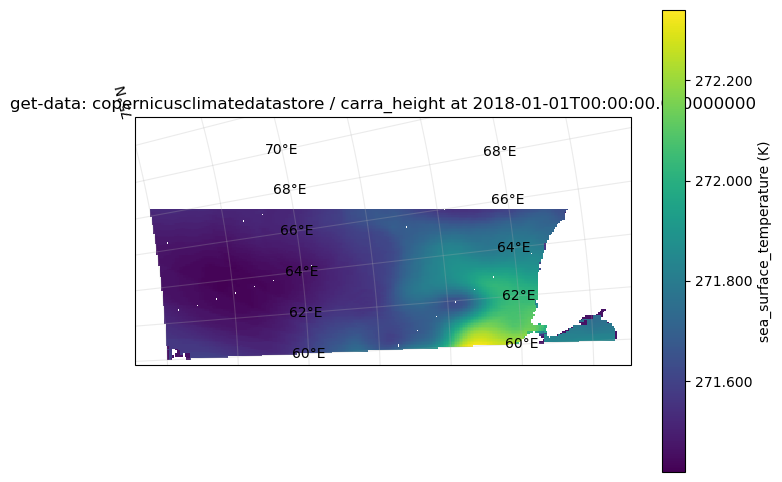


Partially covered CARRA: timeseries
Query input:


{'variable': 'sea_surface_temperature',
 'time_start': '2018-01',
 'time_end': '2018-01',
 'coarseness_factor': 1,
 'time_unit': 'Day',
 'aggregation_method': 'mean',
 'region': {'west': 60.0, 'east': 179.999, 'south': 65.0, 'north': 75.0},
 'repository': 'copernicusclimatedatastore',
 'dataset': 'carra_height',
 'additional_parameters': {'height': '15m'},
 'function': 'timeseries'}

QueryResult
  query_id: eeb918694b4d77e8947ac3f0e373bb24
  function: timeseries
  warnings: ['copernicusclimatedatastore/carra_height/sea_surface_temperature/{"height":"15m","region":"east"} is missing 31 of 62 bucket/time cells at the exact requested grid.']
  unmatched_miss_set: []
  groups: 1

  GroupResult 1
    group_id: d1df36096318efad6597358087ce69e8
    file_path: /Users/bean/polar-is/storage/data/tmp/query_results/eeb918694b4d77e8947ac3f0e373bb24/timeseries/d1df36096318efad6597358087ce69e8.nc
    units: 'K'
    hit_set: [('r5_c1', '2018-01-01T00:00:00'), ('r5_c1', '2018-01-02T00:00:00'), ('r5_c1', '2018-01-03T00:00:00'), ('r5_c1', '2018-01-04T00:00:00'), ('r5_c1', '2018-01-05T00:00:00'), ('r5_c1', '2018-01-06T00:00:00'), ('r5_c1', '2018-01-07T00:00:00'), ('r5_c1', '2018-01-08T00:00:00'), ('r5_c1', '2018-01-09T00:00:00'), ('r5_c1', '2018-01-10T00:00:00'), ('r5_c1', '2018-01-11T00:00:00'), ('r5_c1', '2018-01-12T00:00:00'), ('r5_c1', '2018-01-13T00:00:00'), ('r5_c1', '2018-01-14

<xarray.Dataset> Size: 992B
Dimensions:                  (timestamp: 31)
Coordinates:
  * timestamp                (timestamp) datetime64[ns] 248B 2018-01-01 ... 2...
    expver                   (timestamp) <U4 496B 'prod' 'prod' ... 'prod'
Data variables:
    sea_surface_temperature  (timestamp) float64 248B 271.6 271.7 ... 271.6
Attributes:
    query_id:               eeb918694b4d77e8947ac3f0e373bb24
    group_id:               d1df36096318efad6597358087ce69e8
    function:               timeseries
    repository:             copernicusclimatedatastore
    dataset:                carra_height
    variable:               sea_surface_temperature
    additional_parameters:  {"height": "15m", "region": "east"}
    coarseness_factor:      1
    time_unit:              Day
    aggregation_method:     mean
    block_ids:              ["afaa96a63416b0df4d654ea1fe51b743"]

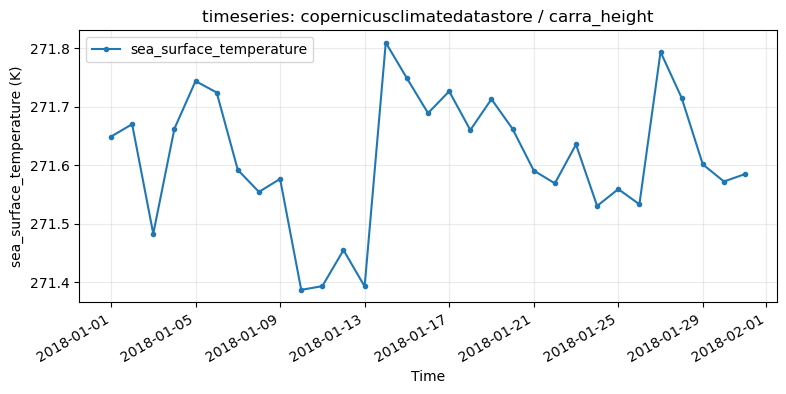


Partially covered CARRA: heatmap
Query input:


{'variable': 'sea_surface_temperature',
 'time_start': '2018-01',
 'time_end': '2018-01',
 'coarseness_factor': 1,
 'time_unit': 'Day',
 'aggregation_method': 'mean',
 'region': {'west': 60.0, 'east': 179.999, 'south': 65.0, 'north': 75.0},
 'repository': 'copernicusclimatedatastore',
 'dataset': 'carra_height',
 'additional_parameters': {'height': '15m'},
 'function': 'heatmap'}

QueryResult
  query_id: e147af07fc48c79774edbf83226fbe8e
  function: heatmap
  warnings: ['copernicusclimatedatastore/carra_height/sea_surface_temperature/{"height":"15m","region":"east"} is missing 31 of 62 bucket/time cells at the exact requested grid.']
  unmatched_miss_set: []
  groups: 1

  GroupResult 1
    group_id: d1df36096318efad6597358087ce69e8
    file_path: /Users/bean/polar-is/storage/data/tmp/query_results/e147af07fc48c79774edbf83226fbe8e/heatmap/d1df36096318efad6597358087ce69e8.nc
    units: 'K'
    hit_set: [('r5_c1', '2018-01-01T00:00:00'), ('r5_c1', '2018-01-02T00:00:00'), ('r5_c1', '2018-01-03T00:00:00'), ('r5_c1', '2018-01-04T00:00:00'), ('r5_c1', '2018-01-05T00:00:00'), ('r5_c1', '2018-01-06T00:00:00'), ('r5_c1', '2018-01-07T00:00:00'), ('r5_c1', '2018-01-08T00:00:00'), ('r5_c1', '2018-01-09T00:00:00'), ('r5_c1', '2018-01-10T00:00:00'), ('r5_c1', '2018-01-11T00:00:00'), ('r5_c1', '2018-01-12T00:00:00'), ('r5_c1', '2018-01-13T00:00:00'), ('r5_c1', '2018-01-14T00:00

<xarray.Dataset> Size: 3MB
Dimensions:                  (cell: 22447)
Coordinates:
  * cell                     (cell) int64 180kB 0 1 2 3 ... 22444 22445 22446
    latitude                 (cell) float64 180kB 74.99 74.96 ... 69.22 69.19
    longitude                (cell) float64 180kB 60.06 60.05 ... 65.27 65.26
    bucket_id                (cell) <U1 90kB 'r' 'r' 'r' 'r' ... 'r' 'r' 'r' 'r'
    cell_id                  (cell) <U27 2MB '74.9871532847,60.0577405395' .....
Data variables:
    sea_surface_temperature  (cell) float64 180kB 271.5 271.6 ... 271.5 271.5
Attributes:
    query_id:               e147af07fc48c79774edbf83226fbe8e
    group_id:               d1df36096318efad6597358087ce69e8
    function:               heatmap
    repository:             copernicusclimatedatastore
    dataset:                carra_height
    variable:               sea_surface_temperature
    additional_parameters:  {"height": "15m", "region": "east"}
    coarseness_factor:      1
    time_unit:              Day
    aggregation_method:     mean
    block_ids:              ["afaa96a63416b0df4d654ea1fe51b743"]

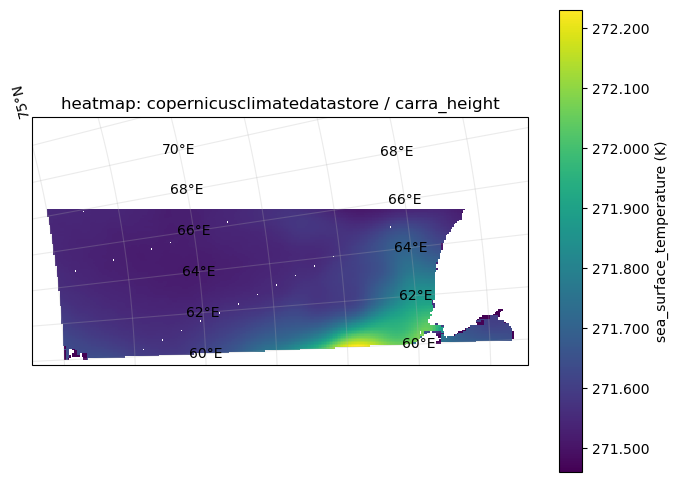


Partially covered CARRA: find-time
Query input:


{'variable': 'sea_surface_temperature',
 'time_start': '2018-01',
 'time_end': '2018-01',
 'coarseness_factor': 1,
 'time_unit': 'Day',
 'aggregation_method': 'mean',
 'region': {'west': 60.0, 'east': 179.999, 'south': 65.0, 'north': 75.0},
 'repository': 'copernicusclimatedatastore',
 'dataset': 'carra_height',
 'additional_parameters': {'height': '15m'},
 'function': 'find-time',
 'predicate': 'gt',
 'filter_value': 271.75}

QueryResult
  query_id: 296bcd20def2374429e9e139427c089c
  function: find-time
  warnings: ['copernicusclimatedatastore/carra_height/sea_surface_temperature/{"height":"15m","region":"east"} is missing 31 of 62 bucket/time cells at the exact requested grid.']
  unmatched_miss_set: []
  groups: 1

  GroupResult 1
    group_id: d1df36096318efad6597358087ce69e8
    file_path: /Users/bean/polar-is/storage/data/tmp/query_results/296bcd20def2374429e9e139427c089c/find-time/d1df36096318efad6597358087ce69e8.nc
    units: 'K'
    hit_set: [('r5_c1', '2018-01-01T00:00:00'), ('r5_c1', '2018-01-02T00:00:00'), ('r5_c1', '2018-01-03T00:00:00'), ('r5_c1', '2018-01-04T00:00:00'), ('r5_c1', '2018-01-05T00:00:00'), ('r5_c1', '2018-01-06T00:00:00'), ('r5_c1', '2018-01-07T00:00:00'), ('r5_c1', '2018-01-08T00:00:00'), ('r5_c1', '2018-01-09T00:00:00'), ('r5_c1', '2018-01-10T00:00:00'), ('r5_c1', '2018-01-11T00:00:00'), ('r5_c1', '2018-01-12T00:00:00'), ('r5_c1', '2018-01-13T00:00:00'), ('r5_c1', '2018-01-14T0

<xarray.Dataset> Size: 1kB
Dimensions:                  (timestamp: 31)
Coordinates:
  * timestamp                (timestamp) datetime64[ns] 248B 2018-01-01 ... 2...
    expver                   (timestamp) <U4 496B 'prod' 'prod' ... 'prod'
Data variables:
    sea_surface_temperature  (timestamp) float64 248B 271.6 271.7 ... 271.6
    matches                  (timestamp) bool 31B False False ... False False
Attributes:
    query_id:               296bcd20def2374429e9e139427c089c
    group_id:               d1df36096318efad6597358087ce69e8
    function:               find-time
    repository:             copernicusclimatedatastore
    dataset:                carra_height
    variable:               sea_surface_temperature
    additional_parameters:  {"height": "15m", "region": "east"}
    coarseness_factor:      1
    time_unit:              Day
    aggregation_method:     mean
    block_ids:              ["afaa96a63416b0df4d654ea1fe51b743"]

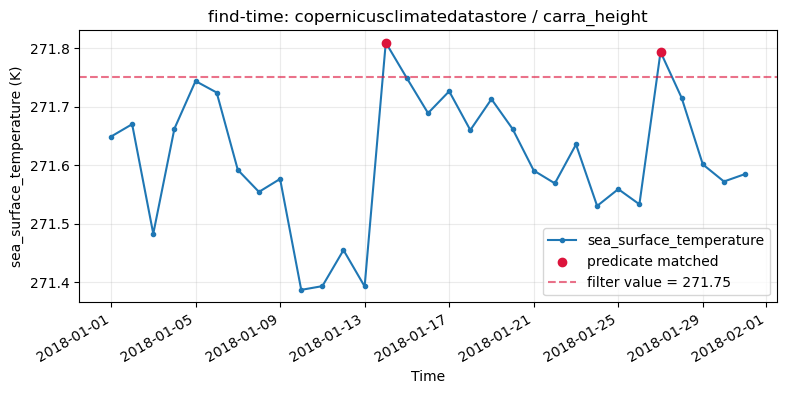


Partially covered CARRA: find-area
Query input:


{'variable': 'sea_surface_temperature',
 'time_start': '2018-01',
 'time_end': '2018-01',
 'coarseness_factor': 1,
 'time_unit': 'Day',
 'aggregation_method': 'mean',
 'region': {'west': 60.0, 'east': 179.999, 'south': 65.0, 'north': 75.0},
 'repository': 'copernicusclimatedatastore',
 'dataset': 'carra_height',
 'additional_parameters': {'height': '15m'},
 'function': 'find-area',
 'predicate': 'gt',
 'filter_value': 271.75}

QueryResult
  query_id: 95cf5675d0e1e0294e71a878465c16b9
  function: find-area
  warnings: ['copernicusclimatedatastore/carra_height/sea_surface_temperature/{"height":"15m","region":"east"} is missing 31 of 62 bucket/time cells at the exact requested grid.']
  unmatched_miss_set: []
  groups: 1

  GroupResult 1
    group_id: d1df36096318efad6597358087ce69e8
    file_path: /Users/bean/polar-is/storage/data/tmp/query_results/95cf5675d0e1e0294e71a878465c16b9/find-area/d1df36096318efad6597358087ce69e8.nc
    units: 'K'
    hit_set: [('r5_c1', '2018-01-01T00:00:00'), ('r5_c1', '2018-01-02T00:00:00'), ('r5_c1', '2018-01-03T00:00:00'), ('r5_c1', '2018-01-04T00:00:00'), ('r5_c1', '2018-01-05T00:00:00'), ('r5_c1', '2018-01-06T00:00:00'), ('r5_c1', '2018-01-07T00:00:00'), ('r5_c1', '2018-01-08T00:00:00'), ('r5_c1', '2018-01-09T00:00:00'), ('r5_c1', '2018-01-10T00:00:00'), ('r5_c1', '2018-01-11T00:00:00'), ('r5_c1', '2018-01-12T00:00:00'), ('r5_c1', '2018-01-13T00:00:00'), ('r5_c1', '2018-01-14T0

<xarray.Dataset> Size: 3MB
Dimensions:                  (cell: 22447)
Coordinates:
  * cell                     (cell) int64 180kB 0 1 2 3 ... 22444 22445 22446
    latitude                 (cell) float64 180kB 74.99 74.96 ... 69.22 69.19
    longitude                (cell) float64 180kB 60.06 60.05 ... 65.27 65.26
    bucket_id                (cell) <U1 90kB 'r' 'r' 'r' 'r' ... 'r' 'r' 'r' 'r'
    cell_id                  (cell) <U27 2MB '74.9871532847,60.0577405395' .....
Data variables:
    sea_surface_temperature  (cell) float64 180kB 271.5 271.6 ... 271.5 271.5
    matches                  (cell) bool 22kB False False False ... False False
Attributes:
    query_id:               95cf5675d0e1e0294e71a878465c16b9
    group_id:               d1df36096318efad6597358087ce69e8
    function:               find-area
    repository:             copernicusclimatedatastore
    dataset:                carra_height
    variable:               sea_surface_temperature
    additional_parameters:  {"height": "15m", "region": "east"}
    coarseness_factor:      1
    time_unit:              Day
    aggregation_method:     mean
    block_ids:              ["afaa96a63416b0df4d654ea1fe51b743"]

/Users/bean/miniconda3/envs/xesmf_figs_env/lib/python3.14/site-packages/cartopy/mpl/geoaxes.py:509: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  return super().draw(renderer=renderer, **kwargs)


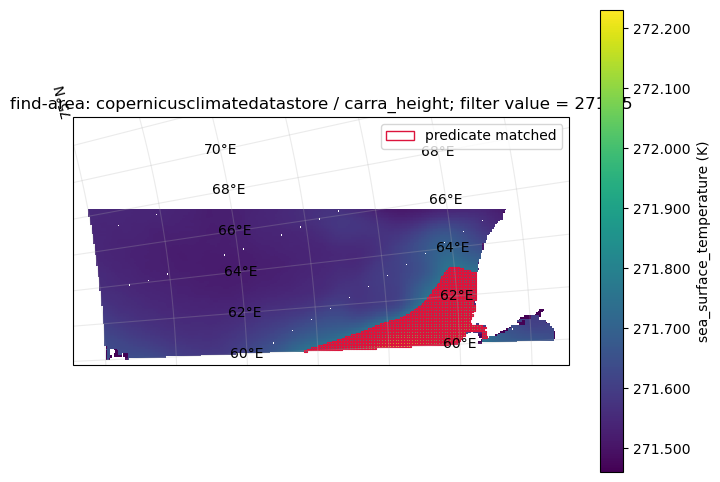

In [8]:
partially_covered_results = run_scenario(
    'Partially covered CARRA', PARTIALLY_COVERED_CARRA
)

## 3. CARRA query outside storage

Here `north` (the maximum latitude) is below zero. No CARRA group data should be returned; the warnings and unmatched miss set are the expected output.

In [ ]:
outside_results = run_scenario('Outside CARRA', OUTSIDE_CARRA)